# A. Import AUTOECONSENTIMENT

In [1]:
import os
import pandas as pd
import yaml
from auto_econ_sentiment.pipeline import AutoEconSentiment
from auto_econ_sentiment.utils.load_yaml import load_yaml_config

# Ensure we are in the project root if running from notebooks directory
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

#print(f"Current working directory: {os.getcwd()}")

## A.1 Synthetic example

In [2]:
# Create synthetic data for demonstration
data = {
    "text": [
        "Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.", 
        "Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",
        "Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",
        "The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.",
        "Economic activity increased fast while maintaining high employment and strong consumer confidence.",
        "Slower growth and weak demand were observed in the second half of the year, leading to low inflation."
    ],
    "date": ["2024-01-01", "2024-02-01", "2024-03-01", "2024-04-01", "2024-05-01", "2024-06-01"]
}
df_demo = pd.DataFrame(data)
csv_demo_path = "data/temp/demo_data.csv"
os.makedirs("data/temp", exist_ok=True)
df_demo.to_csv(csv_demo_path, index=False)
df_demo.head()

,text,date
0,Economic growth remains robust despite global ...,2024-01-01
1,"Inflationary pressures have eased slightly, bu...",2024-02-01
2,Our latest projections indicate a moderate rec...,2024-03-01
3,The committee decided to maintain interest rat...,2024-04-01
4,Economic activity increased fast while maintai...,2024-05-01


# 1. Run autoecon sentiment
## 1.A Initialize autoecon sentiment

In [3]:
# Initialize AutoEconSentiment
analyzer = AutoEconSentiment(
    import_file_path=csv_demo_path,
    text_column="text",
    date_column="date",
    export_path="data/temp/lexical_results"
)
# Load data
df_raw = analyzer.load_data()
df_raw.head(2)

,text,date
0,Economic growth remains robust despite global ...,2024-01-01
1,"Inflationary pressures have eased slightly, bu...",2024-02-01


## 1.1 Clean

In [4]:
# Clean data
# We'll use a basic cleaning configuration
clean_config = {
    "clean_html": True,
    "clean_numbers_percentages": True,
    "remove_headers": [],
    "tokenize": True,
    "stem": True
}

df_clean, df_sentences = analyzer.clean_data(clean_config=clean_config)
df_clean.head()

Tokenizing sentences: 100%|██████████| 6/6 [00:00<00:00, 18993.07it/s]


,text,date,id_text,text_clean,text_tokens,text_tokens_str,text_stems,text_sentences
0,Economic growth remains robust despite global ...,2024-01-01,1,Economic growth remains robust despite global ...,"[economic, growth, remains, robust, despite, g...",economic growth remains robust despite global ...,econom growth remain robust despit global chal...,[Economic growth remains robust despite global...
1,"Inflationary pressures have eased slightly, bu...",2024-02-01,2,"Inflationary pressures have eased slightly, bu...","[inflationary, pressures, have, eased, slightl...",inflationary pressures have eased slightly but...,inflationari pressur have eas slightli but rem...,"[Inflationary pressures have eased slightly, b..."
2,Our latest projections indicate a moderate rec...,2024-03-01,3,Our latest projections indicate a moderate rec...,"[our, latest, projections, indicate, a, modera...",our latest projections indicate a moderate rec...,our latest project indic a moder recoveri howe...,[Our latest projections indicate a moderate re...
3,The committee decided to maintain interest rat...,2024-04-01,4,The committee decided to maintain interest rat...,"[the, committee, decided, to, maintain, intere...",the committee decided to maintain interest rat...,the committe decid to maintain interest rate a...,[The committee decided to maintain interest ra...
4,Economic activity increased fast while maintai...,2024-05-01,5,Economic activity increased fast while maintai...,"[economic, activity, increased, fast, while, m...",economic activity increased fast while maintai...,econom activ increas fast while maintain high ...,[Economic activity increased fast while mainta...


## 1.2 Create sentiment

In [5]:
# Run Lexical Sentiment Analysis
# We'll use a few dictionaries and both aggregation methods
dictionaries = ["correa", "hubert", "lm", "hiv", "ap"]
aggregation_methods = ["allwords", "posneg"]
text_columns = ["text", "text_stems"]

df_sent_lexical = analyzer.analyze_sentiment_lexical(
    dictionaries=dictionaries,
    aggregation_methods=aggregation_methods,
    text_columns=text_columns
)

# Show a sample of the results
df_sent_lexical.head()

auto_econ_sentiment.models.sentiment_lexical - INFO - SentimentLexical initialized with 6 records, text column: 'text'
INFO:auto_econ_sentiment.models.sentiment_lexical:SentimentLexical initialized with 6 records, text column: 'text'
Lexical Methods:   0%|          | 0/5 [00:00<?, ?it/s]auto_econ_sentiment.models.sentiment_lexical - INFO - Starting sentiment pipeline with dictionary 'correa' and method 'allwords'
INFO:auto_econ_sentiment.models.sentiment_lexical:Starting sentiment pipeline with dictionary 'correa' and method 'allwords'
auto_econ_sentiment.models.sentiment_lexical - INFO - Loading dictionary: correa from /Users/cory/Desktop/auto-econ-sentiment/src/auto_econ_sentiment/models/../data/lexical_master_dict.yaml
INFO:auto_econ_sentiment.models.sentiment_lexical:Loading dictionary: correa from /Users/cory/Desktop/auto-econ-sentiment/src/auto_econ_sentiment/models/../data/lexical_master_dict.yaml
auto_econ_sentiment.models.sentiment_lexical - INFO - Dictionary loaded: 1484 tota

,correa_counttoken_positive_allwords,correa_counttoken_negative_allwords,correa_words_positive_allwords,correa_words_negative_allwords,correa_counttoken_total_allwords,correa_sentiment_allwords,correa_counttoken_positive_allwords_stem,correa_counttoken_negative_allwords_stem,correa_words_positive_allwords_stem,correa_words_negative_allwords_stem,...,ap_counttoken_positive_posneg,ap_counttoken_negative_posneg,ap_words_positive_posneg,ap_words_negative_posneg,ap_sentiment_posneg,ap_counttoken_positive_posneg_stem,ap_counttoken_negative_posneg_stem,ap_words_positive_posneg_stem,ap_words_negative_posneg_stem,ap_sentiment_posneg_stem
id_text,,,,,,,,,,,,,,,,,,,,,
1,0,1,{},{'challenges': 1},17,0.941176,0,1,{},{'tension': 1},...,0,0,{},{},1.0,0,0,{},{},1.0
2,0,0,{},{},12,1.000000,0,0,{},{},...,0,0,{},{},1.0,0,0,{},{},1.0
3,1,0,{'recovery': 1},{},10,1.100000,0,1,{},{'tension': 1},...,0,0,{},{},1.0,0,0,{},{},1.0
4,0,0,{},{},10,1.000000,0,0,{},{},...,0,0,{},{},1.0,0,0,{},{},1.0
5,0,0,{},{},10,1.000000,0,0,{},{},...,3,0,"{'fast': 1, 'strong': 1, 'high': 1}",{},2.0,4,0,"{'increas': 1, 'fast': 1, 'strong': 1, 'high': 1}",{},2.0


## 2. Understanding Lexical Results

The `analyze_sentiment_lexical` method produces several columns for each dictionary-method-text combination:
- `counttoken_positive`: Number of positive words found.
- `counttoken_negative`: Number of negative words found.
- `words_positive`: A dictionary of positive words and their frequencies.
- `words_negative`: A dictionary of negative words and their frequencies.
- `sentiment`: The calculated sentiment score.

### Aggregation Methods:
- **posneg**: $1 + \frac{pos - neg}{pos + neg}$
  - Standardized between 0 and 2, where 1.0 is neutral.
  - It ignores the total size of the document, focusing only on the balance of sentiment words.
- **all**: $1 + \frac{pos - neg}{total\_tokens}$
  - Uses total document tokens in the denominator.
  - This accounts for the intensity/density of sentiment relative to the whole text.

## 2.A Show all sentiment measures

In [6]:
# Exploring specific sentiment scores
sentiment_columns = [col for col in df_sent_lexical.columns if 'sentiment' in col]
df_sent_lexical[sentiment_columns].head()

,correa_sentiment_allwords,correa_sentiment_allwords_stem,correa_sentiment_posneg,correa_sentiment_posneg_stem,hubert_sentiment_allwords,hubert_sentiment_allwords_stem,hubert_sentiment_posneg,hubert_sentiment_posneg_stem,lm_sentiment_allwords,lm_sentiment_allwords_stem,lm_sentiment_posneg,lm_sentiment_posneg_stem,hiv_sentiment_allwords,hiv_sentiment_allwords_stem,hiv_sentiment_posneg,hiv_sentiment_posneg_stem,ap_sentiment_allwords,ap_sentiment_allwords_stem,ap_sentiment_posneg,ap_sentiment_posneg_stem
id_text,,,,,,,,,,,,,,,,,,,,
1,0.941176,0.941176,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.941176,1.0,0.0,1.117647,1.0,2.0,1.0,1.0,1.0,1.0,1.0
2,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,1.100000,0.900000,2.0,0.0,1.0,1.0,1.0,1.0,0.9,0.900000,0.0,0.0,1.100000,0.9,2.0,0.0,1.0,1.0,1.0,1.0
4,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
5,1.000000,1.000000,1.0,1.0,1.4,1.3,2.0,2.0,1.1,1.100000,2.0,2.0,1.000000,1.0,1.0,1.0,1.3,1.4,2.0,2.0


In [7]:
df_sent_lexical[sentiment_columns].describe().round(1)

,correa_sentiment_allwords,correa_sentiment_allwords_stem,correa_sentiment_posneg,correa_sentiment_posneg_stem,hubert_sentiment_allwords,hubert_sentiment_allwords_stem,hubert_sentiment_posneg,hubert_sentiment_posneg_stem,lm_sentiment_allwords,lm_sentiment_allwords_stem,lm_sentiment_posneg,lm_sentiment_posneg_stem,hiv_sentiment_allwords,hiv_sentiment_allwords_stem,hiv_sentiment_posneg,hiv_sentiment_posneg_stem,ap_sentiment_allwords,ap_sentiment_allwords_stem,ap_sentiment_posneg,ap_sentiment_posneg_stem
count,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0
mean,1.0,1.0,1.0,0.7,1.0,1.0,1.0,1.0,1.0,1.0,0.9,0.7,1.0,1.0,1.2,0.8,1.0,1.0,1.0,1.0
std,0.1,0.0,0.6,0.5,0.2,0.2,0.6,0.6,0.1,0.1,0.6,0.8,0.1,0.0,0.8,0.4,0.2,0.2,0.6,0.6
min,0.9,0.9,0.0,0.0,0.7,0.7,0.0,0.0,0.9,0.8,0.0,0.0,0.9,0.9,0.0,0.0,0.8,0.8,0.0,0.0
25%,1.0,1.0,1.0,0.2,1.0,1.0,1.0,1.0,0.9,0.9,0.8,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
50%,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
75%,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.1,1.0,1.8,1.0,1.0,1.0,1.0,1.0
max,1.1,1.0,2.0,1.0,1.4,1.3,2.0,2.0,1.1,1.1,2.0,2.0,1.1,1.0,2.0,1.0,1.3,1.4,2.0,2.0


## 2.1 Show example of sentiment and keywords

In [18]:
df_sent_lexical_text = pd.merge(df_clean[['id_text', 'text','date']], df_sent_lexical, on = 'id_text')
df_sent_lexical_text.head(2)

,id_text,text,date,correa_counttoken_positive_allwords,correa_counttoken_negative_allwords,correa_words_positive_allwords,correa_words_negative_allwords,correa_counttoken_total_allwords,correa_sentiment_allwords,correa_counttoken_positive_allwords_stem,...,ap_counttoken_positive_posneg,ap_counttoken_negative_posneg,ap_words_positive_posneg,ap_words_negative_posneg,ap_sentiment_posneg,ap_counttoken_positive_posneg_stem,ap_counttoken_negative_posneg_stem,ap_words_positive_posneg_stem,ap_words_negative_posneg_stem,ap_sentiment_posneg_stem
0,1,Economic growth remains robust despite global ...,2024-01-01,0,1,{},{'challenges': 1},17,0.941176,0,...,0,0,{},{},1.0,0,0,{},{},1.0
1,2,"Inflationary pressures have eased slightly, bu...",2024-02-01,0,0,{},{},12,1.000000,0,...,0,0,{},{},1.0,0,0,{},{},1.0


### 2.1.A Create function to compare

In [19]:
def show_dictionary_example(dictionary):
    return df_sent_lexical_text.set_index(['date','text']).filter(regex=dictionary).filter(regex="words")

### 2.1.1 Compare

In [20]:
show_dictionary_example("correa")

,,correa_counttoken_positive_allwords,correa_counttoken_negative_allwords,correa_words_positive_allwords,correa_words_negative_allwords,correa_counttoken_total_allwords,correa_sentiment_allwords,correa_counttoken_positive_allwords_stem,correa_counttoken_negative_allwords_stem,correa_words_positive_allwords_stem,correa_words_negative_allwords_stem,correa_counttoken_total_allwords_stem,correa_sentiment_allwords_stem,correa_words_positive_posneg,correa_words_negative_posneg,correa_words_positive_posneg_stem,correa_words_negative_posneg_stem
date,text,,,,,,,,,,,,,,,,
2024-01-01,"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.",0,1,{},{'challenges': 1},17,0.941176,0,1,{},{'tension': 1},17,0.941176,{},{'challenges': 1},{},{'tension': 1}
2024-02-01,"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",0,0,{},{},12,1.000000,0,0,{},{},12,1.000000,{},{},{},{}
2024-03-01,"Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",1,0,{'recovery': 1},{},10,1.100000,0,1,{},{'tension': 1},10,0.900000,{'recovery': 1},{},{},{'tension': 1}
2024-04-01,The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.,0,0,{},{},10,1.000000,0,0,{},{},10,1.000000,{},{},{},{}
2024-05-01,Economic activity increased fast while maintaining high employment and strong consumer confidence.,0,0,{},{},10,1.000000,0,0,{},{},10,1.000000,{},{},{},{}
2024-06-01,"Slower growth and weak demand were observed in the second half of the year, leading to low inflation.",0,0,{},{},11,1.000000,0,0,{},{},11,1.000000,{},{},{},{}


In [21]:
show_dictionary_example("lm")

,,lm_counttoken_positive_allwords,lm_counttoken_negative_allwords,lm_words_positive_allwords,lm_words_negative_allwords,lm_counttoken_total_allwords,lm_sentiment_allwords,lm_counttoken_positive_allwords_stem,lm_counttoken_negative_allwords_stem,lm_words_positive_allwords_stem,lm_words_negative_allwords_stem,lm_counttoken_total_allwords_stem,lm_sentiment_allwords_stem,lm_words_positive_posneg,lm_words_negative_posneg,lm_words_positive_posneg_stem,lm_words_negative_posneg_stem
date,text,,,,,,,,,,,,,,,,
2024-01-01,"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.",2,2,"{'despite': 1, 'stability': 1}","{'challenges': 1, 'persist': 1}",17,1.000000,0,1,{},{'persist': 1},17,0.941176,"{'despite': 1, 'stability': 1}","{'challenges': 1, 'persist': 1}",{},{'persist': 1}
2024-02-01,"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",0,0,{},{},12,1.000000,0,0,{},{},12,1.000000,{},{},{},{}
2024-03-01,"Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",0,1,{},{'persist': 1},10,0.900000,0,1,{},{'persist': 1},10,0.900000,{},{'persist': 1},{},{'persist': 1}
2024-04-01,The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.,0,0,{},{},10,1.000000,0,0,{},{},10,1.000000,{},{},{},{}
2024-05-01,Economic activity increased fast while maintaining high employment and strong consumer confidence.,1,0,{'strong': 1},{},10,1.100000,1,0,{'strong': 1},{},10,1.100000,{'strong': 1},{},{'strong': 1},{}
2024-06-01,"Slower growth and weak demand were observed in the second half of the year, leading to low inflation.",1,2,{'leading': 1},"{'slower': 1, 'weak': 1}",11,0.909091,0,2,{},"{'slower': 1, 'weak': 1}",11,0.818182,{'leading': 1},"{'slower': 1, 'weak': 1}",{},"{'slower': 1, 'weak': 1}"


In [22]:
show_dictionary_example("hubert")

,,hubert_counttoken_positive_allwords,hubert_counttoken_negative_allwords,hubert_words_positive_allwords,hubert_words_negative_allwords,hubert_counttoken_total_allwords,hubert_sentiment_allwords,hubert_counttoken_positive_allwords_stem,hubert_counttoken_negative_allwords_stem,hubert_words_positive_allwords_stem,hubert_words_negative_allwords_stem,hubert_counttoken_total_allwords_stem,hubert_sentiment_allwords_stem,hubert_words_positive_posneg,hubert_words_negative_posneg,hubert_words_positive_posneg_stem,hubert_words_negative_posneg_stem
date,text,,,,,,,,,,,,,,,,
2024-01-01,"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.",0,0,{},{},17,1.000000,0,0,{},{},17,1.000000,{},{},{},{}
2024-02-01,"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",0,0,{},{},12,1.000000,0,0,{},{},12,1.000000,{},{},{},{}
2024-03-01,"Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",0,0,{},{},10,1.000000,0,0,{},{},10,1.000000,{},{},{},{}
2024-04-01,The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.,0,0,{},{},10,1.000000,0,0,{},{},10,1.000000,{},{},{},{}
2024-05-01,Economic activity increased fast while maintaining high employment and strong consumer confidence.,4,0,"{'increased': 1, 'fast': 1, 'strong': 1, 'high...",{},10,1.400000,3,0,"{'fast': 1, 'strong': 1, 'high': 1}",{},10,1.300000,"{'increased': 1, 'fast': 1, 'strong': 1, 'high...",{},"{'fast': 1, 'strong': 1, 'high': 1}",{}
2024-06-01,"Slower growth and weak demand were observed in the second half of the year, leading to low inflation.",0,3,{},"{'slower': 1, 'weak': 1, 'low': 1}",11,0.727273,0,3,{},"{'slower': 1, 'weak': 1, 'low': 1}",11,0.727273,{},"{'slower': 1, 'weak': 1, 'low': 1}",{},"{'slower': 1, 'weak': 1, 'low': 1}"


In [23]:
show_dictionary_example("hiv")

,,hiv_counttoken_positive_allwords,hiv_counttoken_negative_allwords,hiv_words_positive_allwords,hiv_words_negative_allwords,hiv_counttoken_total_allwords,hiv_sentiment_allwords,hiv_counttoken_positive_allwords_stem,hiv_counttoken_negative_allwords_stem,hiv_words_positive_allwords_stem,hiv_words_negative_allwords_stem,hiv_counttoken_total_allwords_stem,hiv_sentiment_allwords_stem,hiv_words_positive_posneg,hiv_words_negative_posneg,hiv_words_positive_posneg_stem,hiv_words_negative_posneg_stem
date,text,,,,,,,,,,,,,,,,
2024-01-01,"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.",2,0,"{'robust': 1, 'stability': 1}",{},17,1.117647,1,1,{'robust': 1},{'tension': 1},17,1.0,"{'robust': 1, 'stability': 1}",{},{'robust': 1},{'tension': 1}
2024-02-01,"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",0,0,{},{},12,1.000000,0,0,{},{},12,1.0,{},{},{},{}
2024-03-01,"Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",1,0,{'moderate': 1},{},10,1.100000,0,1,{},{'tension': 1},10,0.9,{'moderate': 1},{},{},{'tension': 1}
2024-04-01,The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.,0,0,{},{},10,1.000000,0,0,{},{},10,1.0,{},{},{},{}
2024-05-01,Economic activity increased fast while maintaining high employment and strong consumer confidence.,0,0,{},{},10,1.000000,0,0,{},{},10,1.0,{},{},{},{}
2024-06-01,"Slower growth and weak demand were observed in the second half of the year, leading to low inflation.",0,1,{},{'inflation': 1},11,0.909091,0,0,{},{},11,1.0,{},{'inflation': 1},{},{}


In [24]:
show_dictionary_example("ap")

,,ap_counttoken_positive_allwords,ap_counttoken_negative_allwords,ap_words_positive_allwords,ap_words_negative_allwords,ap_counttoken_total_allwords,ap_sentiment_allwords,ap_counttoken_positive_allwords_stem,ap_counttoken_negative_allwords_stem,ap_words_positive_allwords_stem,ap_words_negative_allwords_stem,ap_counttoken_total_allwords_stem,ap_sentiment_allwords_stem,ap_words_positive_posneg,ap_words_negative_posneg,ap_words_positive_posneg_stem,ap_words_negative_posneg_stem
date,text,,,,,,,,,,,,,,,,
2024-01-01,"Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.",0,0,{},{},17,1.000000,0,0,{},{},17,1.000000,{},{},{},{}
2024-02-01,"Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",0,0,{},{},12,1.000000,0,0,{},{},12,1.000000,{},{},{},{}
2024-03-01,"Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",0,0,{},{},10,1.000000,0,0,{},{},10,1.000000,{},{},{},{}
2024-04-01,The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.,0,0,{},{},10,1.000000,0,0,{},{},10,1.000000,{},{},{},{}
2024-05-01,Economic activity increased fast while maintaining high employment and strong consumer confidence.,3,0,"{'fast': 1, 'strong': 1, 'high': 1}",{},10,1.300000,4,0,"{'increas': 1, 'fast': 1, 'strong': 1, 'high': 1}",{},10,1.400000,"{'fast': 1, 'strong': 1, 'high': 1}",{},"{'increas': 1, 'fast': 1, 'strong': 1, 'high': 1}",{}
2024-06-01,"Slower growth and weak demand were observed in the second half of the year, leading to low inflation.",0,2,{},"{'weak': 1, 'low': 1}",11,0.818182,0,2,{},"{'weak': 1, 'low': 1}",11,0.818182,{},"{'weak': 1, 'low': 1}",{},"{'weak': 1, 'low': 1}"


## Visualizing Sentiment Trends

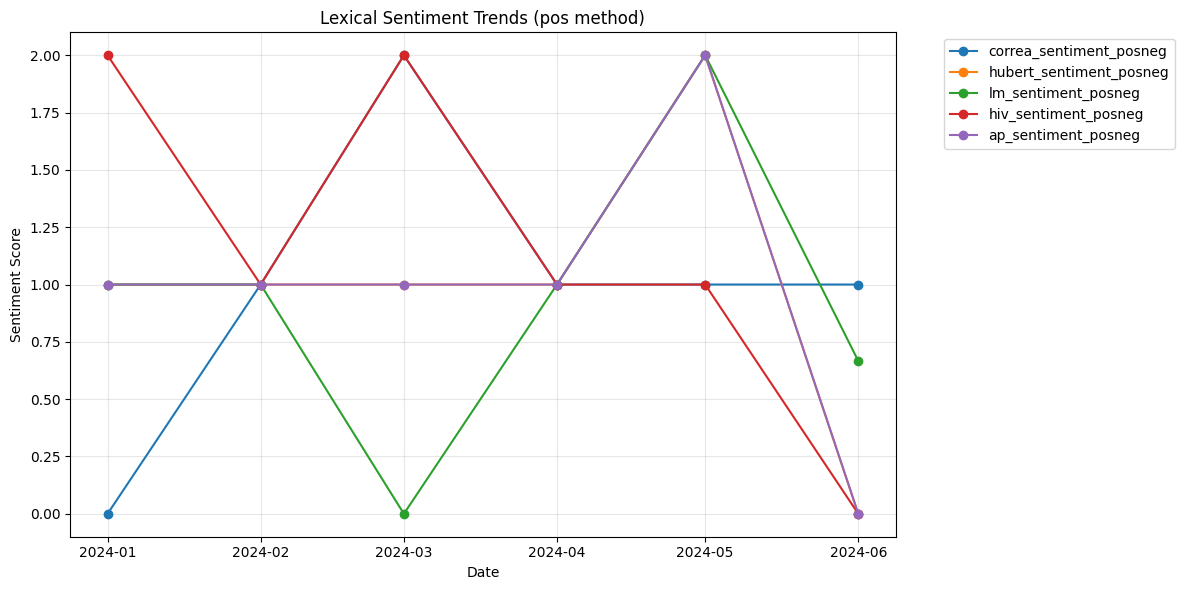

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

df_final = df_sent_lexical_text

plt.figure(figsize=(12, 6))
for col in [c for c in sentiment_columns if 'pos' in c and 'stem' not in c]:
    plt.plot(df_final['date'], df_final[col], label=col, marker='o')

plt.title('Lexical Sentiment Trends (pos method)')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Comparison: Stemming vs. Non-Stemming

Lexical dictionaries can be applied to either raw tokens or stemmed tokens. Stemming can improve coverage by matching variations of words (e.g., "growth", "growing", "grew") to the same root in the dictionary.

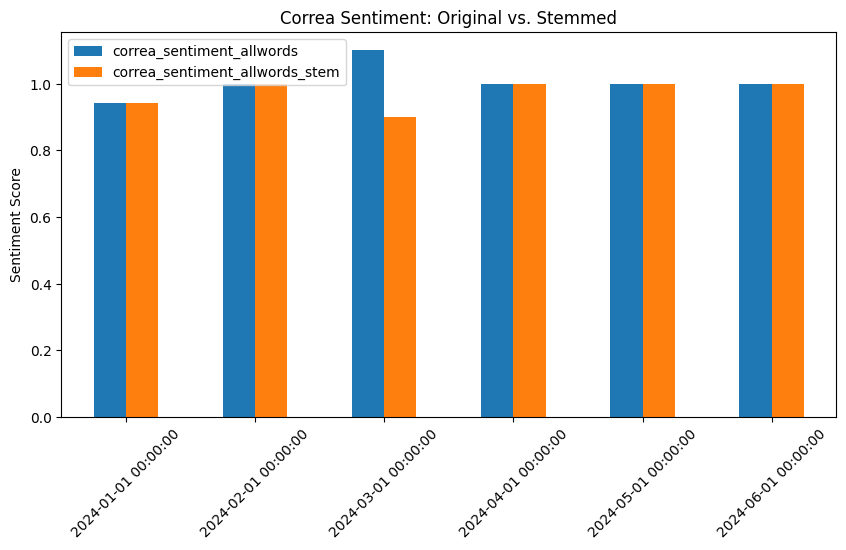

In [27]:
# Compare Correa sentiment with and without stemming
stem_cols = ['correa_sentiment_allwords', 'correa_sentiment_allwords_stem']
df_final[stem_cols].plot(kind='bar', figsize=(10, 5))
plt.title('Correa Sentiment: Original vs. Stemmed')
plt.ylabel('Sentiment Score')
plt.xticks(range(len(df_final)), df_final['date'], rotation=45)
plt.show()

## Loading Previously Exported Results

Once the pipeline has been run, the results are stored in the export path. You can load them directly for further analysis without re-running the analysis.

In [51]:
# # Load the full sentiment results
# export_path = "data/temp/lexical_results"
# df_results = pd.read_csv(f"{export_path}/sentiment_all_results.csv")

# # Load just the lexical components
# df_lexical_only = pd.read_csv(f"{export_path}/sentiment_lexical.csv")

# print(f"Loaded results shape: {df_results.shape}")
# df_results.head()

## Conclusion

In this notebook, we demonstrated how the `AutoEconSentiment` library simplifies lexical sentiment analysis. By providing a unified interface for multiple dictionaries and aggregation methods, it allows researchers to easily compare different sentiment metrics and robustly analyze economic texts.